# synthetic vs calm 数据生成方式 × 算法对比

本 notebook 在 **两种数据生成方式** 下对比 5 种结构学习算法的表现：

**数据生成方式**
- `synthetic`： `synthetic_dataset.SyntheticDataset` (NOTEARS-系谱)
- `calm`     ： `calm_dataset.CalmDataset`        (kaifeng-jin/CALM 系谱)

**对比算法**
- `cd_A`           ： `coordinate_descent.coordinate0.dag_coordinate_descent_l0`
- `cd_A_weakfaith` ： `coordinate_descent.cd_A_weakfaith.dag_coordinate_descent_l0_weakfaith`
- `calm`           ： `kaifeng-jin/CALM` 的 `CALM.calm` 函数
- `golem`          ： `golemMain/src/golem.py` (GOLEM-EV)
- `fges`           ： `fges_compat.TetradSearch` (需 JDK 21+)

所有算法在 *同一样本上* 并行评测，以保证同类比较公平。

## 1. 环境与导入

In [3]:
import logging
import os
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from IPython.display import display
except Exception:
    display = print


def find_repo_root(start: Path) -> Path:
    start = start.resolve()
    for path in [start, *start.parents]:
        if (path / 'calm_dataset.py').exists() and (path / 'coordinate_descent').exists():
            return path
    raise RuntimeError(f'Could not find repo root from {start}')


REPO_ROOT = find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

os.environ['KMP_DUPLICATE_LIB_OK'] = 'TRUE'
if not os.environ.get('JAVA_HOME'):
    _jdk_candidate = r'C:\Program Files\Microsoft\jdk-21.0.10.7-hotspot'
    if os.path.isdir(_jdk_candidate):
        os.environ['JAVA_HOME'] = _jdk_candidate

from MEC import find_v_structures, get_skeleton, is_in_markov_equiv_class
from synthetic_dataset import SyntheticDataset
from calm_dataset import CalmDataset, weight_to_binary_adj
from coordinate_descent.coordinate0 import dag_coordinate_descent_l0
from coordinate_descent.cd_A_weakfaith import dag_coordinate_descent_l0_weakfaith

print('Python   :', sys.version.split()[0])
print('Repo root:', REPO_ROOT)
print('cd_A          : OK')
print('cd_A_weakfaith: OK')

Python   : 3.10.11
Repo root: C:\Users\super\DAG
cd_A          : OK
cd_A_weakfaith: OK


In [4]:
# ── CALM (kaifeng-jin) ────────────────────────────────────────
CALM_REPO_CANDIDATES = [
    Path(os.environ['CALM_REPO']) if os.environ.get('CALM_REPO') else None,
    REPO_ROOT / 'external' / 'CALM',
    REPO_ROOT.parent / 'CALM',
    Path(r'D:\tmp\CALM-inspect'),
]
CALM_REPO = next(
    (p.resolve() for p in CALM_REPO_CANDIDATES
     if p is not None and (p / 'CALM.py').exists()),
    None,
)
CALM_IMPORT_ERROR = None
try:
    if CALM_REPO is None:
        raise FileNotFoundError('CALM repo not found; set $CALM_REPO or clone to external/CALM')
    if str(CALM_REPO) not in sys.path:
        sys.path.insert(0, str(CALM_REPO))
    import torch
    from CALM import calm as calm_algorithm
    HAS_CALM = True
    print(f'CALM      : OK ({CALM_REPO})')
except Exception as exc:
    HAS_CALM = False
    CALM_IMPORT_ERROR = exc
    print(f'CALM unavailable: {exc}')

# ── GOLEM ─────────────────────────────────────────────────────
GOLEM_IMPORT_ERROR = None
try:
    _golem_src = str((REPO_ROOT / 'golemMain' / 'src').resolve())
    if _golem_src not in sys.path:
        sys.path.append(_golem_src)
    from golem import golem as golem_fit
    HAS_GOLEM = True
    print('GOLEM     : OK')
except Exception as exc:
    HAS_GOLEM = False
    GOLEM_IMPORT_ERROR = exc
    print(f'GOLEM unavailable: {exc}')

# ── FGES (Tetrad) ───────────────────────────────────────────────
FGES_IMPORT_ERROR = None
try:
    import fges_compat as _fges_mod
    _probe = pd.DataFrame(np.eye(2), columns=['x0', 'x1'])
    _s = _fges_mod.TetradSearch(_probe)
    _s.set_verbose(False)
    _s.use_sem_bic()
    _s.run_fges()
    del _probe, _s
    HAS_FGES = True
    print('FGES      : OK')
except Exception as exc:
    HAS_FGES = False
    FGES_IMPORT_ERROR = exc
    print(f'FGES unavailable: {exc}')

# ── CPDAG-SHD backend (可选) ───────────────────────────────────────────
try:
    _toolbox = str((REPO_ROOT / 'toolbox').resolve())
    if _toolbox not in sys.path:
        sys.path.append(_toolbox)
    from cdt.metrics import SHD_CPDAG as _SHD_CPDAG
    HAS_CPDAG_SHD = True
except Exception as exc:
    _SHD_CPDAG = None
    HAS_CPDAG_SHD = False
    print(f'CPDAG-SHD backend unavailable (使用 fallback): {exc}')

CALM      : OK (D:\tmp\CALM-inspect)
GOLEM     : OK
FGES      : OK
CPDAG-SHD backend unavailable (使用 fallback): No module named 'GPUtil'


## 2. 实验配置

默认使用较小的规模以保证调试能跑通。有需要可调大 `trials` / `d_list` / `n_list`。

In [5]:
CFG = {
    # ── 实验规模 ──────────────────────────────────────────
    'trials':     2,
    'seed':       42,
    'd_list':     [50],
    'n_list':     [50000],
    'graph_type': 'ER',

    # ── synthetic_dataset ───────────────────────────────────────
    # SyntheticDataset.simulate_er_dag: p = degree/(d-1)
    # → 期望节点度 (node degree)  = degree
    # → 期望边数               = d * degree / 2
    'syn_degree':      1.0,
    'syn_noise_type':  'gaussian_nv',
    'syn_noise_ratio': 1.0,
    'syn_b_scale':     1.0,

    # ── calm_dataset ──────────────────────────────────────────
    # CalmDataset: s0 = round(degree * d) 条 *边* (igraph Erdos_Renyi(m=s0))
    # → 期望节点度  = 2 * degree
    # → 期望边数   = d * degree
    # 想与 syn_degree 对齐 (相同期望节点度): calm_degree = syn_degree / 2
    'calm_degree':           0.5,
    'calm_sem_type':         'gauss',
    'calm_noise_ratio':      4.0,
    'calm_noise_scale_mode': 'variance',
    'calm_b_scale':          1.0,

    # ── 通用 ───────────────────────────────────────────────
    'standardize': True,
    'threshold':   0.05,

    # ── cd_A / cd_A_weakfaith ──────────────────────────────────────
    'cd_T':         50000,
    'cd_lambda_l0': 0.2,
    'wf_tau':       0.05,
    'wf_screening': 'pcorr',
    'wf_combine':   'union',
    'wf_sampling_mode': 'preserve',

    # ── CALM ─────────────────────────────────────────────────
    'calm_lambda1':         0.005,
    'calm_alpha':           0.01,
    'calm_tau':             0.5,
    'calm_rho_init':        1e-5,
    'calm_rho_mult':        3.0,
    'calm_htol':            1e-8,
    'calm_subproblem_iter': 1000,
    'calm_standardize':     False,
    'calm_device':          'cpu',

    # ── GOLEM-EV ───────────────────────────────────────────────
    'golem_num_iter':      30000,
    'golem_learning_rate': 1e-3,
    'golem_lambda1':       2e-2,
    'golem_lambda2':       5.0,

    # ── FGES ───────────────────────────────────────────────────
    'fges_penalty_discount': 1.0,

    # ── 输出 ───────────────────────────────────────────────
    'out_dir': str((REPO_ROOT / 'experiments' / 'results').resolve()),
    'tag':     'syn_vs_calm_algorithms',
}
os.makedirs(CFG['out_dir'], exist_ok=True)

DATA_SOURCES = ['synthetic', 'calm']
ALGORITHMS_REQUESTED = ['cd_A', 'cd_A_weakfaith', 'calm', 'golem', 'fges']

print(f"d_list      : {CFG['d_list']}")
print(f"n_list      : {CFG['n_list']}")
print(f"trials      : {CFG['trials']}")
print(f"syn_degree  : {CFG['syn_degree']}  -> 期望节点度 ≈ {CFG['syn_degree']:.2f}")
print(f"calm_degree : {CFG['calm_degree']}  -> 期望节点度 ≈ {2*CFG['calm_degree']:.2f}")
print(f"data sources: {DATA_SOURCES}")
print(f"algorithms  : {ALGORITHMS_REQUESTED}")

d_list      : [50]
n_list      : [50000]
trials      : 2
syn_degree  : 1.0  -> 期望节点度 ≈ 1.00
calm_degree : 0.5  -> 期望节点度 ≈ 1.00
data sources: ['synthetic', 'calm']
algorithms  : ['cd_A', 'cd_A_weakfaith', 'calm', 'golem', 'fges']


## 3. 辅助函数 与 统一数据生成器

In [6]:
def standardize_columns(X: np.ndarray) -> np.ndarray:
    scale = X.std(axis=0, keepdims=True)
    scale = np.where(scale > 0, scale, 1.0)
    return (X - X.mean(axis=0, keepdims=True)) / scale


def sample_covariance(X: np.ndarray) -> np.ndarray:
    Xc = X - X.mean(axis=0, keepdims=True)
    return Xc.T @ Xc / Xc.shape[0]


def shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    G_true = np.asarray(G_true, dtype=int)
    G_est  = np.asarray(G_est,  dtype=int)
    d, dist = G_true.shape[0], 0
    for i in range(d):
        for j in range(i + 1, d):
            if G_true[i, j] != G_est[i, j] or G_true[j, i] != G_est[j, i]:
                dist += 1
    return float(dist)


def cpdag_shd_score(G_true: np.ndarray, G_est: np.ndarray) -> float:
    if HAS_CPDAG_SHD:
        try:
            return float(_SHD_CPDAG(G_true.astype(int), G_est.astype(int)))
        except Exception:
            pass
    skel_true = get_skeleton(G_true)
    skel_est  = get_skeleton(G_est)
    skel_diff = int(np.sum(np.abs(skel_true - skel_est)) // 2)
    v_diff    = len(find_v_structures(G_true).symmetric_difference(find_v_structures(G_est)))
    return float(skel_diff + v_diff)


def precision_recall_f1(G_true, G_est):
    true_edge = G_true == 1
    pred_edge = G_est == 1
    tp = int(np.sum(true_edge & pred_edge))
    fp = int(np.sum((~true_edge) & pred_edge))
    fn = int(np.sum(true_edge & (~pred_edge)))
    p = tp / (tp + fp) if tp + fp > 0 else 0.0
    r = tp / (tp + fn) if tp + fn > 0 else 0.0
    f1 = 2 * p * r / (p + r) if p + r > 0 else 0.0
    return float(p), float(r), float(f1)


def evaluate_graph(G_true: np.ndarray, G_est: np.ndarray) -> dict:
    G_est = np.asarray(G_est, dtype=int).copy()
    np.fill_diagonal(G_est, 0)
    p, r, f1 = precision_recall_f1(G_true, G_est)
    return {
        'mec_match':     int(is_in_markov_equiv_class(G_true, G_est)),
        'shd':           shd_score(G_true, G_est),
        'cpdag_shd':     cpdag_shd_score(G_true, G_est),
        'precision':     p,
        'recall':        r,
        'f1':            f1,
        'n_edges_est':   int(G_est.sum()),
    }


def fges_matrix_to_adj(df_result) -> np.ndarray:
    mat = df_result.values if hasattr(df_result, 'values') else df_result
    d   = mat.shape[0]
    G   = np.zeros((d, d), dtype=int)
    for i in range(d):
        for j in range(i + 1, d):
            a, b = int(mat[i, j]), int(mat[j, i])
            if   a == 2 and b == 3: G[i, j] = 1
            elif a == 3 and b == 2: G[j, i] = 1
            elif a == 3 and b == 3: G[i, j] = G[j, i] = 1
            elif a != 0 or  b != 0: G[i, j] = G[j, i] = 1
    np.fill_diagonal(G, 0)
    return G


def make_dataset(source: str, d: int, n: int, seed: int):
    """Return (X, G_true) for the given data-generation source.

    NOTE: SyntheticDataset 与 CalmDataset 的 ``degree`` 参数语义不同，
    分别使用 CFG['syn_degree'] 与 CFG['calm_degree']。详细见配置 cell 注释。
    """
    if source == 'synthetic':
        ds = SyntheticDataset(
            n=n, d=d,
            graph_type=CFG['graph_type'],
            degree=CFG['syn_degree'],
            noise_type=CFG['syn_noise_type'],
            B_scale=CFG['syn_b_scale'],
            seed=int(seed),
            noise_ratio=CFG['syn_noise_ratio'],
        )
        G_true = (np.abs(ds.B) > 0).astype(int)
        np.fill_diagonal(G_true, 0)
        return ds.X, G_true
    elif source == 'calm':
        ds = CalmDataset(
            n=n, d=d,
            graph_type=CFG['graph_type'],
            degree=CFG['calm_degree'],
            sem_type=CFG['calm_sem_type'],
            seed=int(seed),
            noise_ratio=CFG['calm_noise_ratio'],
            noise_scale_mode=CFG['calm_noise_scale_mode'],
            b_scale=CFG['calm_b_scale'],
        )
        G_true = weight_to_binary_adj(ds.B)
        return ds.X, G_true
    raise ValueError(f'unknown data source: {source!r}')


print('辅助函数已定义。')

辅助函数已定义。


## 4. 算法封装

In [7]:
def _failure(msg: str) -> dict:
    return {'status': 'failed', 'G_est': None, 'message': str(msg)}


def run_cd_A(X, S, seed):
    A, G_est, obj = dag_coordinate_descent_l0(
        S=S, T=CFG['cd_T'], seed=seed,
        threshold=CFG['threshold'], lambda_l0=CFG['cd_lambda_l0'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_cd_A_weakfaith(X, S, seed):
    A, G_est, obj = dag_coordinate_descent_l0_weakfaith(
        S=S, T=CFG['cd_T'], seed=seed,
        threshold=CFG['threshold'], lambda_l0=CFG['cd_lambda_l0'],
        faithfulness_tau=CFG['wf_tau'],
        screening=CFG['wf_screening'],
        combine=CFG['wf_combine'],
        sampling_mode=CFG['wf_sampling_mode'],
    )
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_calm(X, S, seed):
    if not HAS_CALM:
        return _failure(f'CALM unavailable: {CALM_IMPORT_ERROR}')
    np.random.seed(seed)
    torch.manual_seed(seed)
    B_w = calm_algorithm(
        X,
        lambda1=CFG['calm_lambda1'],
        alpha=CFG['calm_alpha'],
        tau=CFG['calm_tau'],
        rho_init=CFG['calm_rho_init'],
        rho_mult=CFG['calm_rho_mult'],
        htol=CFG['calm_htol'],
        subproblem_iter=CFG['calm_subproblem_iter'],
        standardize=CFG['calm_standardize'],
        device=CFG['calm_device'],
    )
    G_est = (np.abs(np.asarray(B_w)) > 0).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_golem(X, S, seed):
    if not HAS_GOLEM:
        return _failure(f'GOLEM unavailable: {GOLEM_IMPORT_ERROR}')
    B_est = golem_fit(
        X,
        lambda_1=CFG['golem_lambda1'],
        lambda_2=CFG['golem_lambda2'],
        equal_variances=True,
        num_iter=CFG['golem_num_iter'],
        learning_rate=CFG['golem_learning_rate'],
        seed=int(seed),
    )
    G_est = (np.abs(np.asarray(B_est)) > CFG['threshold']).astype(int)
    np.fill_diagonal(G_est, 0)
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


def run_fges(X, S, seed):
    if not HAS_FGES:
        return _failure(f'FGES unavailable: {FGES_IMPORT_ERROR}')
    cols = [f'x{i}' for i in range(X.shape[1])]
    df_X = pd.DataFrame(X, columns=cols).astype('float64')
    search = _fges_mod.TetradSearch(df_X)
    search.set_verbose(False)
    search.use_sem_bic(penalty_discount=CFG['fges_penalty_discount'])
    search.run_fges()
    G_est = fges_matrix_to_adj(search.get_graph_to_matrix())
    return {'status': 'ok', 'G_est': G_est, 'message': ''}


ALGORITHMS = {
    'cd_A':           run_cd_A,
    'cd_A_weakfaith': run_cd_A_weakfaith,
    'calm':           run_calm,
    'golem':          run_golem,
    'fges':           run_fges,
}
ALGORITHMS = {k: ALGORITHMS[k] for k in ALGORITHMS_REQUESTED if k in ALGORITHMS}
list(ALGORITHMS)

['cd_A', 'cd_A_weakfaith', 'calm', 'golem', 'fges']

## 5. 运行对比

外层循环： `data_source → (d, n) → trial → algorithm`。同一 trial 上所有算法共享同一份样本与真实图。

In [8]:
rng = np.random.default_rng(CFG['seed'])
rows = []
skip_logs = []
last_graphs = {}  # (data_source, alg) -> G_est ; ('true', data_source) -> G_true

for d in CFG['d_list']:
    for n_samples in CFG['n_list']:
        trial_seeds = rng.integers(0, 10**9, size=CFG['trials'])
        for source in DATA_SOURCES:
            for trial_id, data_seed_raw in enumerate(trial_seeds, start=1):
                data_seed = int(data_seed_raw)
                X_raw, G_true = make_dataset(source, d, n_samples, data_seed)
                X = standardize_columns(X_raw) if CFG['standardize'] else X_raw
                S = sample_covariance(X)
                last_graphs[('true', source)] = G_true

                for alg_idx, (alg_name, runner) in enumerate(ALGORITHMS.items()):
                    alg_seed = data_seed + 1009 * (alg_idx + 1)
                    t0 = time.perf_counter()
                    try:
                        result = runner(X, S, alg_seed)
                    except Exception as exc:
                        result = _failure(exc)
                    runtime_sec = time.perf_counter() - t0

                    base = {
                        'data_source':  source,
                        'algorithm':    alg_name,
                        'd':            d,
                        'n_samples':    n_samples,
                        'trial_id':     trial_id,
                        'data_seed':    data_seed,
                        'status':       result['status'],
                        'n_edges_true': int(G_true.sum()),
                        'runtime_sec':  float(runtime_sec),
                        'message':      result.get('message', ''),
                    }

                    if result['status'] == 'ok':
                        metrics = evaluate_graph(G_true, result['G_est'])
                        row = {**base, **metrics}
                        last_graphs[(source, alg_name)] = result['G_est']
                        print(
                            f'[{source:9s}|{alg_name:14s}] '
                            f"d={d} n={n_samples} trial={trial_id} "
                            f"shd={row['shd']:.0f} cpdag_shd={row['cpdag_shd']:.0f} "
                            f"f1={row['f1']:.3f} rt={runtime_sec:.2f}s"
                        )
                    else:
                        row = {
                            **base,
                            'mec_match': 0,
                            'shd': np.nan, 'cpdag_shd': np.nan,
                            'precision': np.nan, 'recall': np.nan, 'f1': np.nan,
                            'n_edges_est': np.nan,
                        }
                        skip_logs.append({**base})
                        print(f'[SKIP {source}|{alg_name}] {result["message"]}')
                    rows.append(row)

df_trials = pd.DataFrame(rows)
display(df_trials)

[synthetic|cd_A          ] d=50 n=50000 trial=1 shd=27 cpdag_shd=26 f1=0.339 rt=27.26s
[synthetic|cd_A_weakfaith] d=50 n=50000 trial=1 shd=8 cpdag_shd=4 f1=0.755 rt=28.23s
[synthetic|calm          ] d=50 n=50000 trial=1 shd=17 cpdag_shd=21 f1=0.564 rt=118.47s

[synthetic|golem         ] d=50 n=50000 trial=1 shd=76 cpdag_shd=87 f1=0.164 rt=324.70s
[synthetic|fges          ] d=50 n=50000 trial=1 shd=10 cpdag_shd=3 f1=0.848 rt=8.19s
[synthetic|cd_A          ] d=50 n=50000 trial=2 shd=26 cpdag_shd=26 f1=0.407 rt=26.25s
[synthetic|cd_A_weakfaith] d=50 n=50000 trial=2 shd=16 cpdag_shd=10 f1=0.500 rt=26.37s
[synthetic|calm          ] d=50 n=50000 trial=2 shd=19 cpdag_shd=21 f1=0.476 rt=108.98s
[synthetic|golem         ] d=50 n=50000 trial=2 shd=56 cpdag_shd=58 f1=0.295 rt=308.74s
[synthetic|fges          ] d=50 n=50000 trial=2 shd=21 cpdag_shd=19 f1=0.716 rt=9.05s
[calm     |cd_A          ] d=50 n=50000 trial=1 shd=15 cpdag_shd=15 f1=0.520 rt=27.70s
[calm     |cd_A_weakfaith] d=50 n=50000 tri

,data_source,algorithm,d,n_samples,trial_id,data_seed,status,n_edges_true,runtime_sec,message,mec_match,shd,cpdag_shd,precision,recall,f1,n_edges_est
0,synthetic,cd_A,50,50000,1,89250953,ok,28,27.264528,,0,27.0,26.0,0.322581,0.357143,0.338983,31
1,synthetic,cd_A_weakfaith,50,50000,1,89250953,ok,28,28.233514,,0,8.0,4.0,0.800000,0.714286,0.754717,25
2,synthetic,calm,50,50000,1,89250953,ok,28,118.474902,,0,17.0,21.0,1.000000,0.392857,0.564103,11
3,synthetic,golem,50,50000,1,89250953,ok,28,324.698934,,0,76.0,87.0,0.106383,0.357143,0.163934,94
4,synthetic,fges,50,50000,1,89250953,ok,28,8.188541,,0,10.0,3.0,0.736842,1.000000,0.848485,38
5,synthetic,cd_A,50,50000,2,773956048,ok,29,26.251014,,0,26.0,26.0,0.400000,0.413793,0.406780,30
6,synthetic,cd_A_weakfaith,50,50000,2,773956048,ok,29,26.366282,,0,16.0,10.0,0.565217,0.448276,0.500000,23
7,synthetic,calm,50,50000,2,773956048,ok,29,108.977485,,0,19.0,21.0,0.769231,0.344828,0.476190,13
8,synthetic,golem,50,50000,2,773956048,ok,29,308.737147,,0,56.0,58.0,0.193548,0.620690,0.295082,93
9,synthetic,fges,50,50000,2,773956048,ok,29,9.053844,,0,21.0,19.0,0.557692,1.000000,0.716049,52


## 6. 汇总与保存

In [9]:
ok = df_trials[df_trials['status'] == 'ok'].copy()
if ok.empty:
    print('No successful runs.')
    df_summary = pd.DataFrame()
else:
    df_summary = (
        ok.groupby(['data_source', 'algorithm', 'd', 'n_samples'], as_index=False)
          .agg(
              trials             = ('trial_id',     'count'),
              mec_match_mean     = ('mec_match',    'mean'),
              shd_mean           = ('shd',          'mean'),
              shd_std            = ('shd',          'std'),
              cpdag_shd_mean     = ('cpdag_shd',    'mean'),
              precision_mean     = ('precision',    'mean'),
              recall_mean        = ('recall',       'mean'),
              f1_mean            = ('f1',           'mean'),
              n_edges_true_mean  = ('n_edges_true', 'mean'),
              n_edges_est_mean   = ('n_edges_est',  'mean'),
              runtime_sec_mean   = ('runtime_sec',  'mean'),
          )
          .sort_values(['data_source', 'd', 'n_samples', 'shd_mean'])
          .reset_index(drop=True)
    )
    display(df_summary)

from datetime import datetime
_ts = datetime.now().strftime('%Y%m%d_%H%M%S')
_trials_path  = os.path.join(CFG['out_dir'], f"{CFG['tag']}_trials_{_ts}.csv")
_summary_path = os.path.join(CFG['out_dir'], f"{CFG['tag']}_summary_{_ts}.csv")
df_trials.to_csv(_trials_path, index=False)
if not df_summary.empty:
    df_summary.to_csv(_summary_path, index=False)
print(f'\nsaved trials  -> {_trials_path}')
if not df_summary.empty:
    print(f'saved summary -> {_summary_path}')

,data_source,algorithm,d,n_samples,trials,mec_match_mean,shd_mean,shd_std,cpdag_shd_mean,precision_mean,recall_mean,f1_mean,n_edges_true_mean,n_edges_est_mean,runtime_sec_mean
0,calm,cd_A_weakfaith,50,50000,2,0.5,10.0,2.828427,4.0,0.640000,0.640000,0.640000,25.0,25.0,28.583894
1,calm,fges,50,50000,2,0.0,14.5,2.121320,8.5,0.612127,0.940000,0.740686,25.0,38.5,7.814265
2,calm,cd_A,50,50000,2,0.0,15.5,0.707107,13.5,0.510000,0.520000,0.514902,25.0,25.5,29.786017
3,calm,calm,50,50000,2,0.0,18.0,1.414214,21.0,0.875000,0.280000,0.424242,25.0,8.0,112.465137
4,calm,golem,50,50000,2,0.0,63.0,22.627417,93.0,0.119816,0.360000,0.178544,25.0,78.0,343.542017
5,synthetic,cd_A_weakfaith,50,50000,2,0.0,12.0,5.656854,7.0,0.682609,0.581281,0.627358,28.5,24.0,27.299898
6,synthetic,fges,50,50000,2,0.0,15.5,7.778175,11.0,0.647267,1.000000,0.782267,28.5,45.0,8.621193
7,synthetic,calm,50,50000,2,0.0,18.0,1.414214,21.0,0.884615,0.368842,0.520147,28.5,12.0,113.726193
8,synthetic,cd_A,50,50000,2,0.0,26.5,0.707107,26.0,0.361290,0.385468,0.372881,28.5,30.5,26.757771
9,synthetic,golem,50,50000,2,0.0,66.0,14.142136,72.5,0.149966,0.488916,0.229508,28.5,93.5,316.718041



saved trials  -> C:\Users\super\DAG\experiments\results\syn_vs_calm_algorithms_trials_20260509_213259.csv
saved summary -> C:\Users\super\DAG\experiments\results\syn_vs_calm_algorithms_summary_20260509_213259.csv


## 7. synthetic vs calm 并排对比 (表格)

In [10]:
if not ok.empty:
    pivot_metrics = ['shd', 'cpdag_shd', 'f1', 'mec_match', 'runtime_sec']
    for metric in pivot_metrics:
        pv = (ok.groupby(['algorithm', 'data_source'])[metric]
                .mean()
                .unstack('data_source'))
        if {'synthetic', 'calm'}.issubset(pv.columns):
            pv['delta (calm - synthetic)'] = pv['calm'] - pv['synthetic']
        print(f'\n=== mean {metric} (rows=algorithm, cols=data_source) ===')
        display(pv.round(4))


=== mean shd (rows=algorithm, cols=data_source) ===


data_source,calm,synthetic,delta (calm - synthetic)
algorithm,,,
calm,18.0,18.0,0.0
cd_A,15.5,26.5,-11.0
cd_A_weakfaith,10.0,12.0,-2.0
fges,14.5,15.5,-1.0
golem,63.0,66.0,-3.0



=== mean cpdag_shd (rows=algorithm, cols=data_source) ===


data_source,calm,synthetic,delta (calm - synthetic)
algorithm,,,
calm,21.0,21.0,0.0
cd_A,13.5,26.0,-12.5
cd_A_weakfaith,4.0,7.0,-3.0
fges,8.5,11.0,-2.5
golem,93.0,72.5,20.5



=== mean f1 (rows=algorithm, cols=data_source) ===


data_source,calm,synthetic,delta (calm - synthetic)
algorithm,,,
calm,0.4242,0.5201,-0.0959
cd_A,0.5149,0.3729,0.1420
cd_A_weakfaith,0.6400,0.6274,0.0126
fges,0.7407,0.7823,-0.0416
golem,0.1785,0.2295,-0.0510



=== mean mec_match (rows=algorithm, cols=data_source) ===


data_source,calm,synthetic,delta (calm - synthetic)
algorithm,,,
calm,0.0,0.0,0.0
cd_A,0.0,0.0,0.0
cd_A_weakfaith,0.5,0.0,0.5
fges,0.0,0.0,0.0
golem,0.0,0.0,0.0



=== mean runtime_sec (rows=algorithm, cols=data_source) ===


data_source,calm,synthetic,delta (calm - synthetic)
algorithm,,,
calm,112.4651,113.7262,-1.2611
cd_A,29.7860,26.7578,3.0282
cd_A_weakfaith,28.5839,27.2999,1.2840
fges,7.8143,8.6212,-0.8069
golem,343.5420,316.7180,26.8240


## 8. 可视化对比

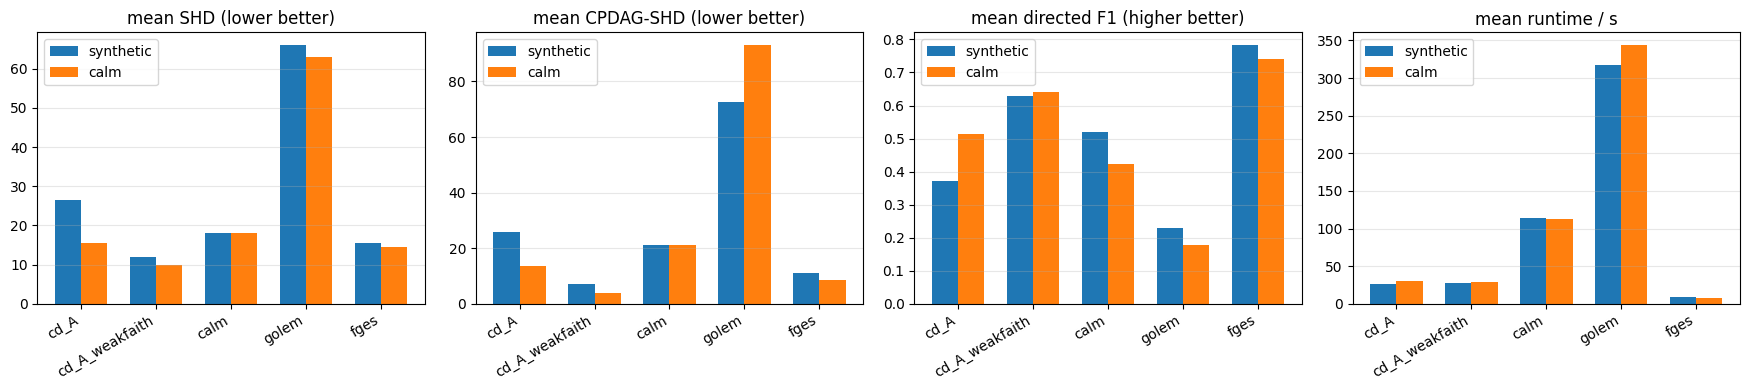

In [11]:
if not ok.empty:
    metrics_to_plot = [
        ('shd',        'mean SHD (lower better)'),
        ('cpdag_shd',  'mean CPDAG-SHD (lower better)'),
        ('f1',         'mean directed F1 (higher better)'),
        ('runtime_sec','mean runtime / s'),
    ]
    fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(4.4 * len(metrics_to_plot), 4))
    algs   = list(ALGORITHMS.keys())
    x_pos  = np.arange(len(algs))
    width  = 0.35

    for ax, (metric, title) in zip(axes, metrics_to_plot):
        means = (ok.groupby(['algorithm', 'data_source'])[metric]
                   .mean()
                   .unstack('data_source')
                   .reindex(algs))
        for i, src in enumerate(DATA_SOURCES):
            if src in means.columns:
                ax.bar(x_pos + (i - 0.5) * width, means[src].values,
                       width=width, label=src)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(algs, rotation=30, ha='right')
        ax.set_title(title)
        ax.grid(alpha=0.3, axis='y')
        ax.legend()
    plt.tight_layout()
    plt.show()

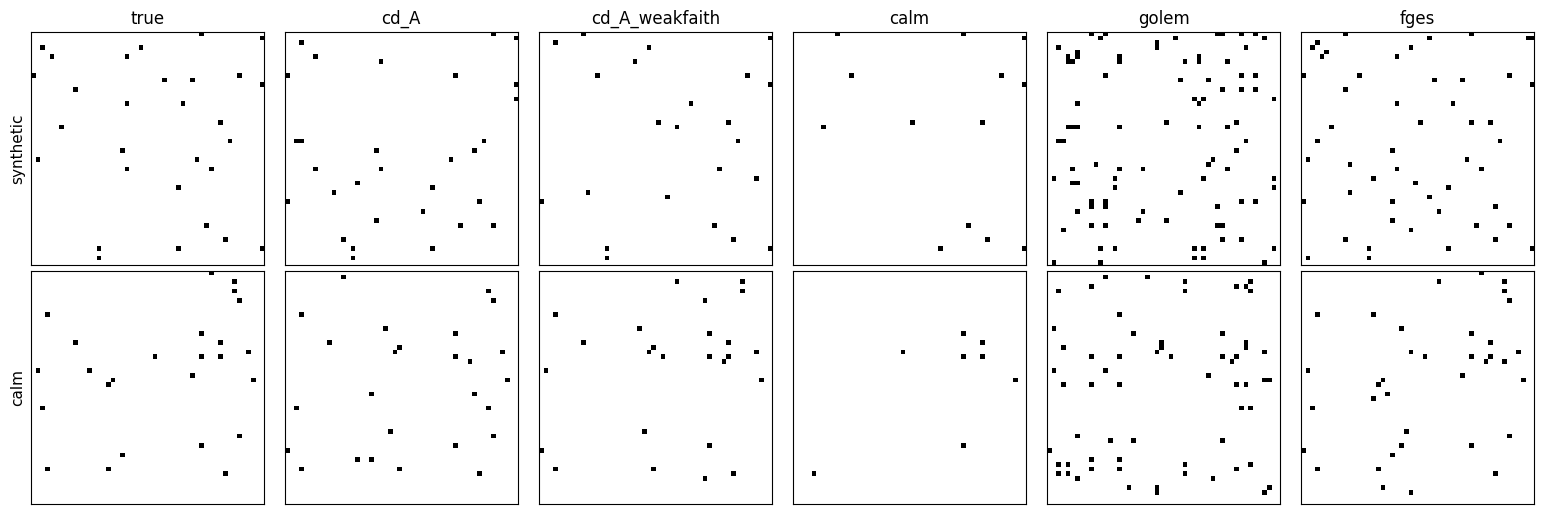

In [12]:
# 最后一次 trial 的估计图 vs 真实图
if last_graphs:
    cols = ['true'] + list(ALGORITHMS.keys())
    fig, axes = plt.subplots(
        len(DATA_SOURCES), len(cols),
        figsize=(2.6 * len(cols), 2.6 * len(DATA_SOURCES)),
        squeeze=False,
    )
    for r, src in enumerate(DATA_SOURCES):
        for c, key in enumerate(cols):
            ax = axes[r][c]
            if key == 'true':
                G = last_graphs.get(('true', src))
            else:
                G = last_graphs.get((src, key))
            if G is None:
                ax.text(0.5, 0.5, 'N/A', ha='center', va='center')
                ax.set_xticks([]); ax.set_yticks([])
            else:
                ax.imshow(G, cmap='Greys', vmin=0, vmax=1)
                ax.set_xticks([]); ax.set_yticks([])
            if r == 0:
                ax.set_title(key)
            if c == 0:
                ax.set_ylabel(src, fontsize=11)
    plt.tight_layout()
    plt.show()

## 9. 跳过记录

In [13]:
if skip_logs:
    df_skip = pd.DataFrame(skip_logs)
    display(df_skip)
else:
    print('所有 trial 均运行成功。')

所有 trial 均运行成功。
